\\Customer_churn_prediction

\Importing necessary libraries

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report,roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import pickle
import os

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

\loading the dataset

In [95]:
df=pd.read_csv(r'C:\NG\customer-churn-prediction\data\customer_churn_business_dataset.csv')

\understanding the data

In [96]:
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


** loaded the dataset and viewed first 5 rows

In [97]:
df.shape

(10000, 32)

** dataset has 10000 rows and 32 columns

In [98]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

In [99]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


** viewed column,it's data types and the statistical values of numeric columns

Insights:
--Age: 18 to 74, average 46 — mixed customer base

--Tenure: 1 to 59 months, average 30 months — most are mid-term users

--Monthly fee: ₹10 to ₹100, average ₹35

--NPS score: -100 to +100 (very wide range — strong signal for churn)

--Payment failures: Average 0.5, max 5 — most customers pay reliably

## Feature Descriptions

The dataset contains **32 features** covering customer demographics, product usage, billing, support interactions, and engagement signals.

| Feature | Type | Description |
|---|---|---|
| `customer_id` | ID | Unique customer identifier — dropped before modelling |
| `gender` | Categorical | Male / Female |
| `age` | Numerical | Customer age in years (18-74) |
| `country` | Categorical | Country of residence |
| `city` | Categorical | City of residence — high cardinality, dropped before modelling |
| `customer_segment` | Categorical | Individual / SME / Enterprise |
| `tenure_months` | Numerical | Months since the customer joined (1-59) |
| `signup_channel` | Categorical | Web / Mobile / Partner |
| `contract_type` | Categorical | Monthly / Quarterly / Yearly |
| `monthly_logins` | Numerical | Login count per month (0-54) |
| `weekly_active_days` | Numerical | Active days per week (0-7) |
| `avg_session_time` | Numerical | Average session duration in minutes |
| `features_used` | Numerical | Number of distinct product features used |
| `usage_growth_rate` | Numerical | Month-over-month usage growth rate (-0.58 to +0.54) |
| `last_login_days_ago` | Numerical | Days elapsed since last login (0-80) |
| `monthly_fee` | Numerical | Monthly subscription fee |
| `total_revenue` | Numerical | Lifetime revenue from the customer |
| `payment_method` | Categorical | Credit Card / Bank Transfer / Digital Wallet / etc. |
| `payment_failures` | Numerical | Count of failed payment attempts (0-5) |
| `discount_applied` | Categorical | Whether a discount was applied (Yes / No) |
| `price_increase_last_3m` | Categorical | Whether price was raised in last 3 months (Yes / No) |
| `support_tickets` | Numerical | Number of support tickets raised |
| `avg_resolution_time` | Numerical | Average hours to resolve a support ticket |
| `complaint_type` | Categorical | Billing / Service / Technical / No Complaint — 20.45% missing, filled as 'no complaint' |
| `csat_score` | Numerical | Customer Satisfaction score (1-5) |
| `escalations` | Numerical | Number of escalated support issues |
| `email_open_rate` | Numerical | Proportion of marketing emails opened (0.1-0.9) |
| `marketing_click_rate` | Numerical | Proportion of marketing email clicks (0.01-0.5) |
| `nps_score` | Numerical | Net Promoter Score (-100 to +100) |
| `survey_response` | Categorical | Satisfied / Neutral / Unsatisfied |
| `referral_count` | Numerical | Number of customers referred (0-7) |
| `churn` | **Target** | 1 = Churned, 0 = Stayed — 10.21% churn rate (imbalanced) |

**Key churn risk signals identified from domain knowledge:**
- Low `csat_score` / `nps_score` — dissatisfied customers are far more likely to leave
- High `last_login_days_ago` — disengagement strongly precedes churn
- High `payment_failures` — billing friction erodes customer trust
- Short `tenure_months` — newly acquired customers have not yet built loyalty
- Billing / Service `complaint_type` — unresolved complaints are leading churn drivers

checking missing values

In [100]:
(df.isnull().sum()/len(df)*100).sort_values(ascending = False)

complaint_type            20.45
customer_id                0.00
age                        0.00
gender                     0.00
city                       0.00
customer_segment           0.00
tenure_months              0.00
country                    0.00
contract_type              0.00
monthly_logins             0.00
weekly_active_days         0.00
avg_session_time           0.00
features_used              0.00
usage_growth_rate          0.00
last_login_days_ago        0.00
signup_channel             0.00
monthly_fee                0.00
total_revenue              0.00
payment_failures           0.00
payment_method             0.00
discount_applied           0.00
price_increase_last_3m     0.00
support_tickets            0.00
avg_resolution_time        0.00
csat_score                 0.00
escalations                0.00
email_open_rate            0.00
marketing_click_rate       0.00
nps_score                  0.00
survey_response            0.00
referral_count             0.00
churn   

In [101]:
#checking for duplicates records
print(df.duplicated().sum())

0


** There is 20.45% of missing values in complaint_type and there is no duplicate records.

** we will fill those missing values in complaint_type as 'no complaint'

\Filling missing values

In [102]:
df['complaint_type'].fillna('no complaint',inplace=True)

0            Service
1            Billing
2            Service
3          Technical
4          Technical
            ...     
9995         Service
9996    no complaint
9997       Technical
9998    no complaint
9999       Technical
Name: complaint_type, Length: 10000, dtype: str

\Target distribution 

In [103]:
churn_pct = df['churn'].value_counts(normalize=True) * 100
print(churn_pct)

churn
0    89.79
1    10.21
Name: proportion, dtype: float64


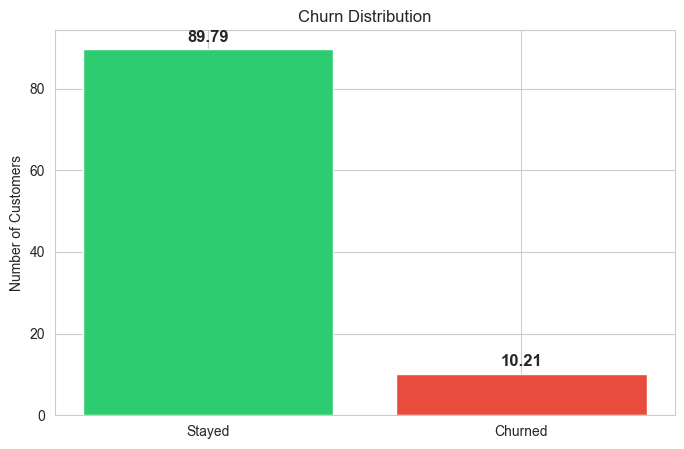

In [104]:
#visual of target variable

plt.figure(figsize=(8, 5))
bars = plt.bar(['Stayed', 'Churned'], churn_pct, color=['#2ecc71', '#e74c3c'])
plt.bar_label(bars, fontsize=12, fontweight='bold', padding=3)
plt.title('Churn Distribution')
plt.ylabel('Number of Customers')
plt.show()

** data is heavily imbalanced with 89% stayed and 10% churned.we will solve this with SMOTE before training the data

\EDA

\Categorical feature analysis

In [105]:
#separating categorical col
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
cat_cols.remove('customer_id')
cat_cols

['gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

\visualise categorical col with target col

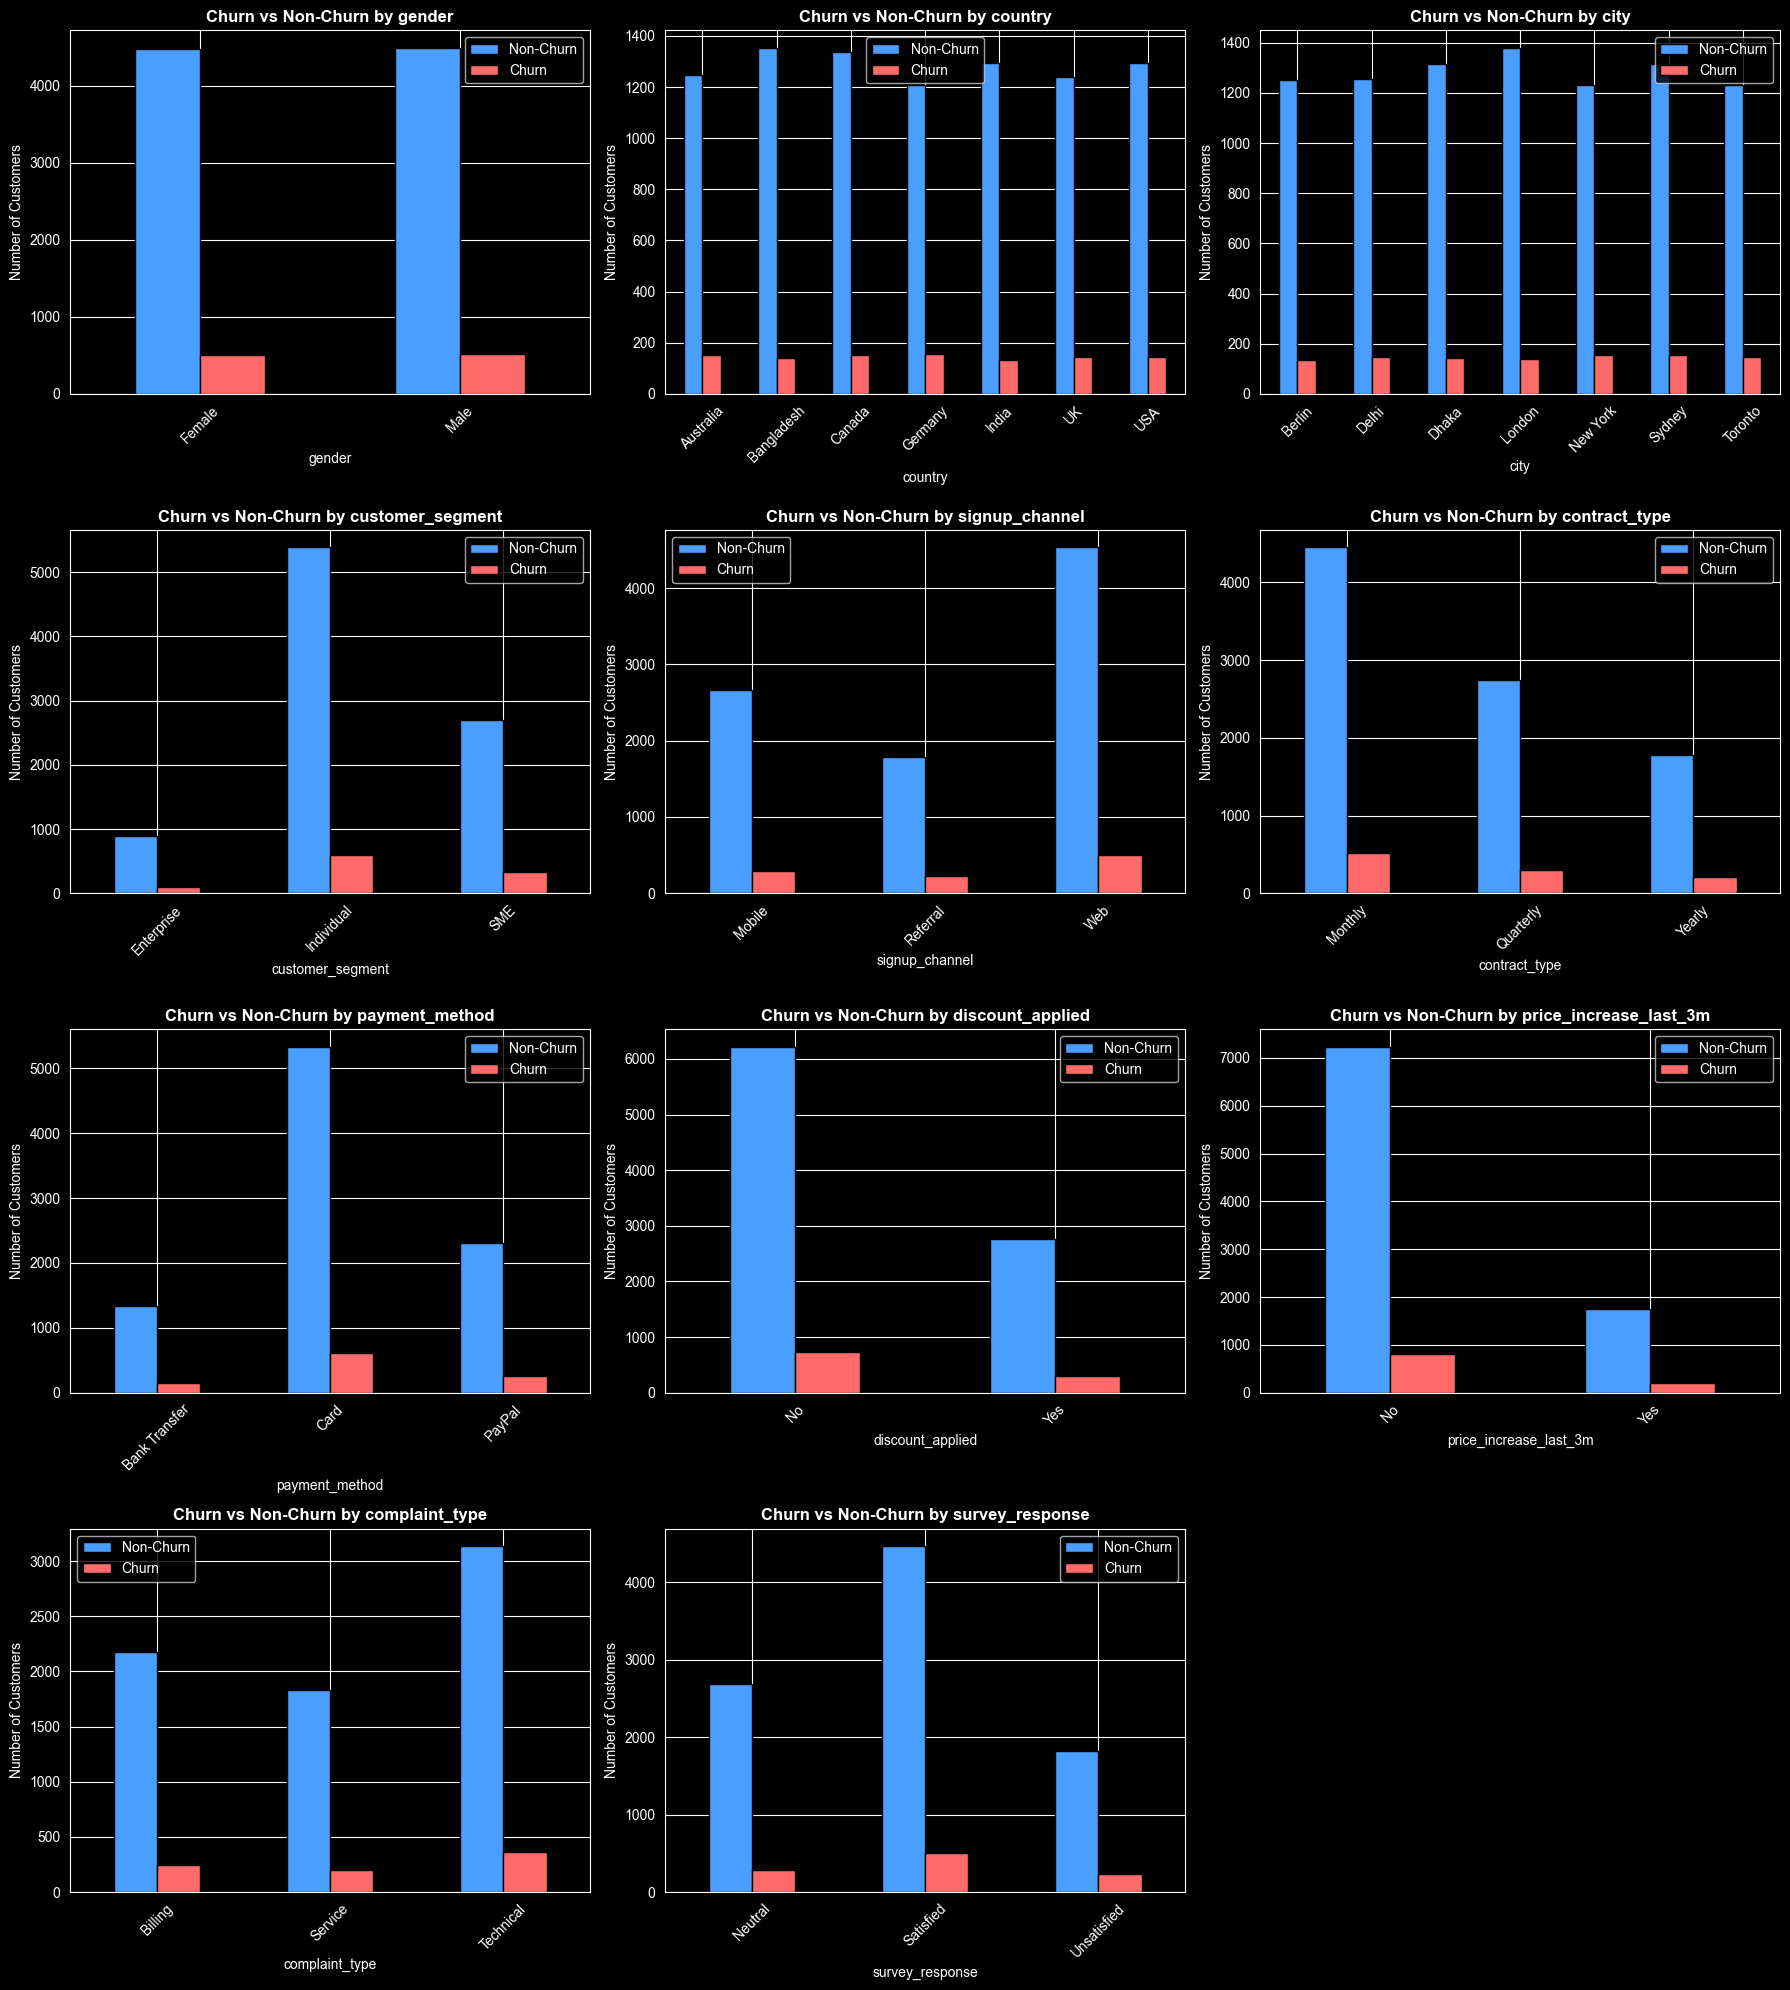

In [106]:
plt.style.use('dark_background')

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df.groupby([col, 'churn']).size().unstack(fill_value=0)
    counts.columns = ['Non-Churn', 'Churn']
    counts.plot(kind='bar', ax=axes[i], color=['#4a9eff', '#ff6b6b'], edgecolor='black')
    axes[i].set_title(f'Churn vs Non-Churn by {col}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Number of Customers')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='')

for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

\INSIGHTS

* **Customer Segment:** Individual customers have a higher churn rate compared to enterprise customers.

* **Signup Channel:** Customers who signed up through the web channel show significantly higher churn than other signup methods.

* **Contract Type:** Customers with monthly contracts are more likely to churn than those with quarterly or yearly subscriptions.

* **Complaint Type:** Customers with billing complaints have the highest churn rate, followed by service complaints, while customers with no complaints show the lowest churn.

* **Survey Results:** Customers who rated their experience as “bad” had the highest churn rate, whereas customers who rated it as “good” had the lowest churn rate.

\Numercial column analysis with tagert

In [107]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove('churn')

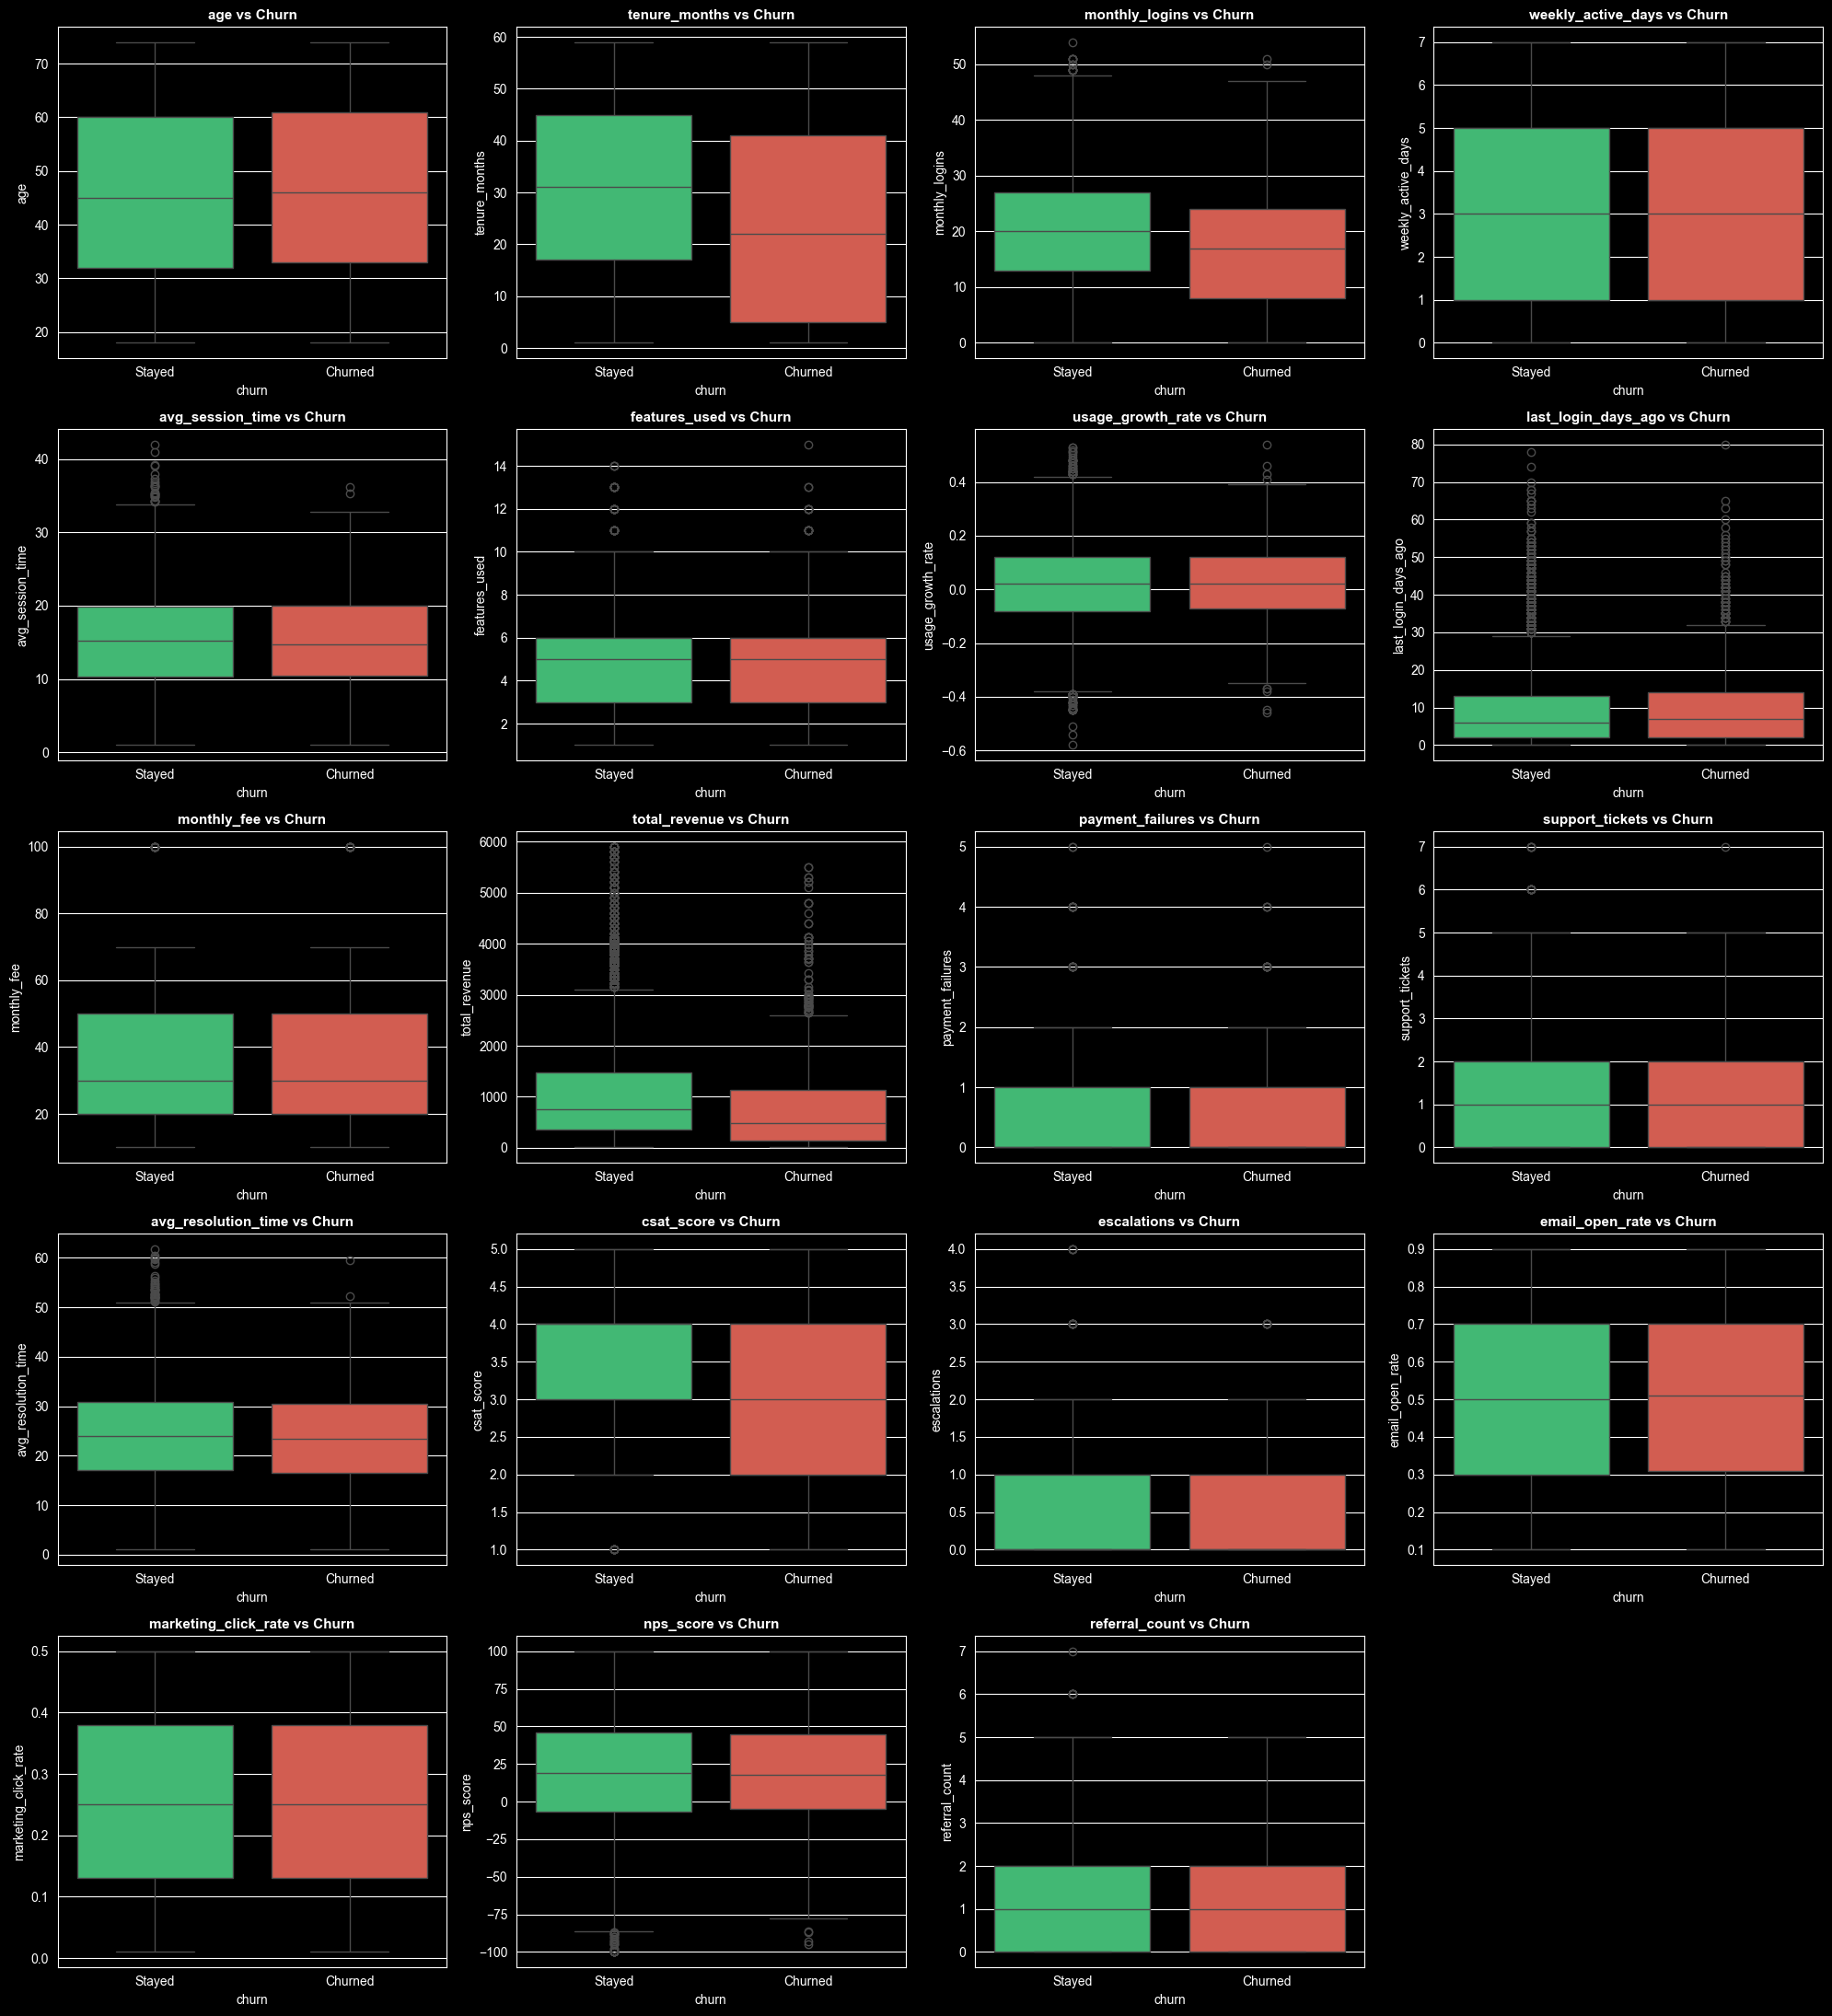

In [108]:
# Boxplots: churn vs numerical features
fig, axes = plt.subplots(5, 4, figsize=(20, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='churn', y=col, ax=axes[i], palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} vs Churn', fontsize=11, fontweight='bold')
    axes[i].set_xticklabels(['Stayed', 'Churned'])

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Insights:

* Customers who haven’t logged in for a long time ago are more likely to churn, showing that inactive users gradually lose engagement and leave the service.
* Lower NPS scores are strongly linked with churn, indicating that customers who are less likely to recommend the product are also more likely to stop using it.
* Customers with lower CSAT scores tend to churn more often, suggesting that dissatisfaction with the overall experience plays a major role in customer loss.
* A higher number of support tickets is commonly seen among churned customers, which points to unresolved issues or repeated problems affecting retention.
* Customers facing more payment failures are more likely to leave, highlighting how billing or transaction issues negatively impact customer trust and continuity.
* Users with shorter tenure show a higher tendency to churn, meaning newer customers are at greater risk of leaving before building long-term engagement with the platform.

\churn correlation 


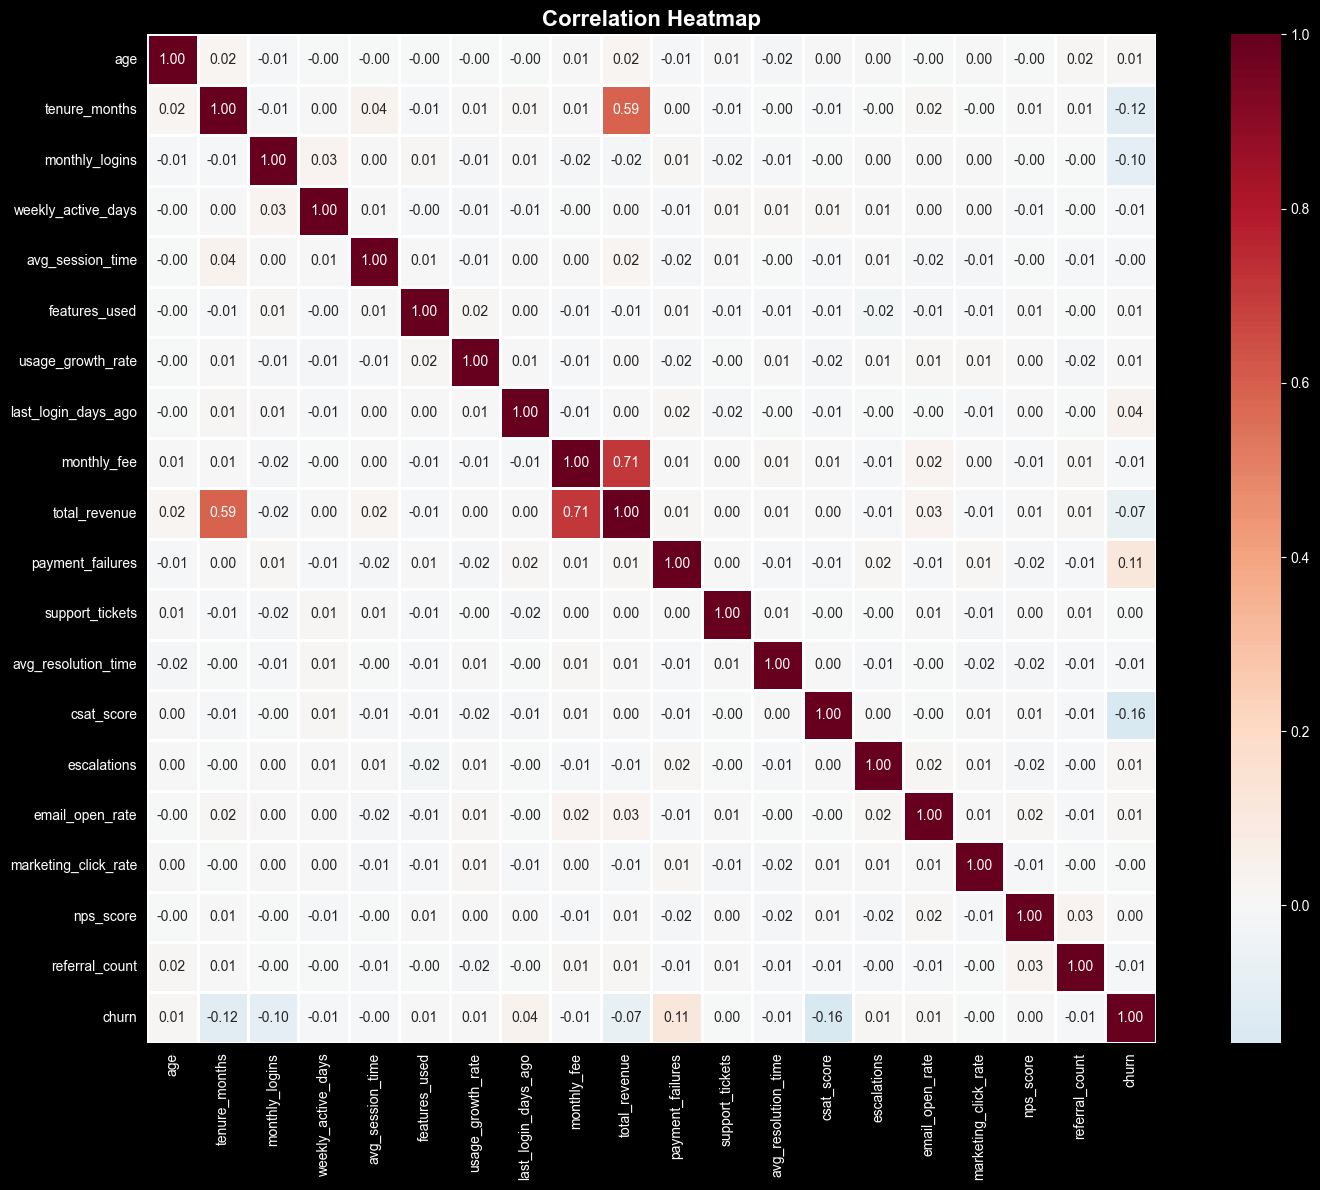

In [109]:
# Correlation with target
numerical_with_target = numeric_cols + ['churn']
corr_matrix = df[numerical_with_target].corr()

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1)
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Insights:
* No single feature strongly predicts churn, indicating churn is influenced by multiple factors together.

* Lower `csat_score` and fewer `monthly_logins` are linked with higher churn, showing that unhappy and less engaged customers are more likely to leave.

* Customers with more `payment_failures` tend to churn more, highlighting billing issues as a major risk factor.

* New customers (`tenure_months` low) are more likely to churn compared to long-term customers.

* `monthly_fee`, `total_revenue`, and `tenure_months` are strongly related, meaning they contain overlapping information.

\Data preprocessing 

Dropping unwanted columns

** customer_id is not useful.So dropping that

In [110]:
df=df.drop('customer_id', axis=1)

In [111]:
df.shape

(10000, 31)

\Feature Engineering

Crerating new features which are useful for the model building

In [112]:
df['revenue_per_month'] = df['total_revenue'] / df['tenure_months']

In [113]:
df['is_inactive'] = (df['last_login_days_ago'] > 14).astype(int)

In [114]:
df['has_complaint'] = (df['complaint_type'] != 'no complaint').astype(int)

In [115]:
df['support_intensity'] = df['support_tickets'] / (df['tenure_months'] + 1)

In [116]:
df['low_engagement'] = (df['email_open_rate'] < 0.3).astype(int)

In [117]:
revenue_threshold = df['total_revenue'].quantile(0.75)
df['is_high_value'] = (df['total_revenue'] > revenue_threshold).astype(int)

In [118]:
#checking newly created feature
df[['revenue_per_month', 'is_inactive', 'has_complaint', 'support_intensity', 'low_engagement', 'is_high_value']].head()

,revenue_per_month,is_inactive,has_complaint,support_intensity,low_engagement,is_high_value
0,30.0,0,1,0.173913,0,0
1,30.0,0,1,0.100000,0,0
2,20.0,1,1,0.016949,0,0
3,30.0,1,1,0.150000,0,0
4,50.0,0,1,0.000000,0,1



Features Added
1. **`revenue_per_month`** → Normalizes revenue by tenure; identifies true monthly customer value .
2. **`is_inactive`** → Binary flag for users not logged in 14+ days; inactive users are strongest churn predictors.
3. **`has_complaint`** → Simplifies complaint history into a clear risk signal for the model.
4. **`support_intensity`** → Captures complaint *rate* (per month) instead of raw count; fair comparison between old and new customers.
5. **`low_engagement`** → Flags users opening <30% emails; disengagement precedes churn.
6. **`is_high_value`** → Marks top 25% revenue customers; helps prioritize retention efforts.



\Separating independent and dependent features

In [119]:
# Drop target + multicollinear (total_revenue) + high-cardinality (city)
X = df.drop(['churn', 'total_revenue', 'city'], axis=1)
Y = df['churn']

\Binary encoding

In [120]:
binary_cols = ['gender', 'discount_applied', 'price_increase_last_3m']
label_encoders = {}

for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [121]:
X[binary_cols].head()

,gender,discount_applied,price_increase_last_3m
0,1,1,0
1,0,0,1
2,1,0,0
3,1,1,0
4,1,0,0


** Binary classification columns in the data are converted into numeric using learnencode

\One hot encoding
converting multiple category column using get_dummies

In [122]:
multiclass_cols = ['country', 'customer_segment', 'signup_channel',
                   'contract_type', 'payment_method', 'complaint_type', 'survey_response']
X = pd.get_dummies(X, columns=multiclass_cols, drop_first=True)

\coverting boolen into int

In [123]:
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)


\Spliting the data into train and test set

In [124]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.20, random_state=42,stratify=Y)

\feature scaling

**bringing all the numeric col into same scale

In [125]:
binary_features = [col for col in X_train.columns if X_train[col].nunique() == 2]
col_to_scale = [col for col in X_train.columns if col not in binary_features]

scaler= StandardScaler()
X_train[col_to_scale]= scaler.fit_transform(X_train[col_to_scale])
X_test[col_to_scale]= scaler.transform(X_test[col_to_scale])

In [126]:
X_train[col_to_scale].head()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,payment_failures,...,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,revenue_per_month,has_complaint,support_intensity
3529,-0.240659,-0.423840,0.027367,1.087419,-1.980728,-0.454115,-1.000280,1.992799,-1.044507,-0.706409,...,0.174283,0.526189,-0.537129,-0.869705,-0.316064,1.001303,-0.995846,-1.044507,0.0,-0.498405
8625,1.405500,-0.716027,0.843546,1.087419,-0.677429,-0.003381,-0.866760,-0.152316,-0.204871,0.702534,...,0.375954,0.526189,-0.537129,-1.259120,-1.740576,0.358536,0.009171,-0.204871,0.0,-0.151516
9234,-1.155192,-1.358840,0.027367,1.087419,-1.011074,-0.454115,0.868996,-0.254464,1.474400,0.702534,...,-0.358207,-0.498273,-0.537129,-0.177411,1.607028,-0.335653,-0.995846,1.474400,0.0,0.325457
5779,1.405500,0.686472,-2.013079,-1.515878,1.192790,-0.003381,-0.065642,3.014283,2.733853,3.520419,...,-0.368010,-0.498273,-0.537129,-0.826437,0.894772,0.101429,-0.995846,2.733853,0.0,-0.345128
8440,-1.581975,1.153972,-2.013079,-1.081996,1.293716,1.799557,-0.132402,-0.152316,-0.624689,0.702534,...,1.680560,-1.522735,1.301566,-1.648536,0.681095,0.564221,2.019204,-0.624689,0.0,-0.369171


\Fixing data imbalance using SMOTE

In [127]:
smote=SMOTE(random_state=42,k_neighbors=5)
X_train_balanced,Y_train_balanced =smote.fit_resample(X_train,Y_train)

In [128]:
print(Y_train_balanced.value_counts())

churn
0    7183
1    7183
Name: count, dtype: int64


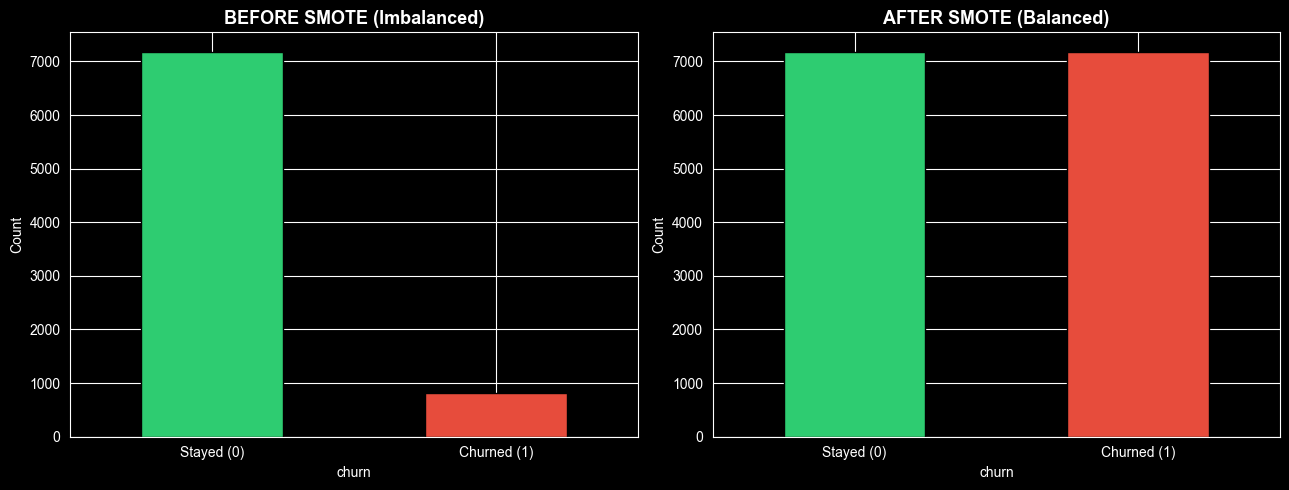

In [129]:
# Visualize before vs after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Before
Y_train.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('BEFORE SMOTE (Imbalanced)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('Count')

# After
Y_train_balanced.value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('AFTER SMOTE (Balanced)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

\Model 1: Logistic Regression

In [130]:
lr=LogisticRegression(random_state=42,max_iter=1000)
lr.fit(X_train_balanced,Y_train_balanced)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [131]:
Y_pred=lr.predict(X_test)
Y_proba=lr.predict_proba(X_test)[:,1]


\Evaluation

In [132]:
confusion_matrix(Y_test,Y_pred)

array([[1586,  210],
       [ 168,   36]])

In [133]:
print(" Quick Performance Preview:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_pred):.4f}")

 Quick Performance Preview:
   Accuracy:  0.8110
   Precision: 0.1463
   Recall:    0.1765
   F1-Score:  0.1600
   ROC-AUC:   0.5298


Since the model is not perfoming well where the precesion and recall are very low,checking the model by changing the threshold probability

In [134]:
Y_pred_threshold = (Y_proba > 0.3).astype(int)

In [135]:
confusion_matrix(Y_test,Y_pred_threshold)

array([[1378,  418],
       [ 133,   71]])

In [136]:
print(" Quick Performance Preview:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_threshold):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_threshold):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_threshold):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_threshold):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_pred_threshold):.4f}")

 Quick Performance Preview:
   Accuracy:  0.7245
   Precision: 0.1452
   Recall:    0.3480
   F1-Score:  0.2049
   ROC-AUC:   0.5576


Since changing the threshold value it is not performing well.So lets do hyperparameter tuning and build a model

\HYPERPARAMETER TUNING

In [137]:
print(" Tuning Logistic Regression...\n")

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],          
    'penalty': ['l1', 'l2'],           
    'solver': ['liblinear']           
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=5,                   
    scoring='f1',            
    n_jobs=-1,             
    verbose=1
)

lr_grid.fit(X_train_balanced, Y_train_balanced)

print(f"\n Best parameters: {lr_grid.best_params_}")
print(f" Best CV F1-score: {lr_grid.best_score_:.4f}")

# Save the best tuned model
best_lr = lr_grid.best_estimator_

# Evaluate on test set
Y_pred_lr_t = best_lr.predict(X_test)
Y_proba_lr_t = best_lr.predict_proba(X_test)[:, 1]



 Tuning Logistic Regression...

Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
 Best CV F1-score: 0.8529


In [138]:
print(" Quick Performance Preview:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_lr_t):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_lr_t):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_lr_t):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_lr_t):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_proba_lr_t):.4f}")

 Quick Performance Preview:
   Accuracy:  0.8120
   Precision: 0.1532
   Recall:    0.1863
   F1-Score:  0.1681
   ROC-AUC:   0.6170


Even after hyperparameter tuning in logistic regression model..the model is not performing well..so building next model

\Model 2: Random Forest

In [139]:
rf = RandomForestClassifier(
    n_estimators=500,        
    max_depth=12,            
    min_samples_split=10,    
    min_samples_leaf=5,     
    random_state=42,
    n_jobs=-1               
)


In [140]:
rf.fit(X_train_balanced, Y_train_balanced)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [141]:
Y_pred_rf = rf.predict(X_test)
Y_proba_rf = rf.predict_proba(X_test)[:, 1]



# Metrics
print(" Random Forest Performance:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_rf):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_rf):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_rf):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_rf):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_proba_rf):.4f}")

 Random Forest Performance:
   Accuracy:  0.8605
   Precision: 0.2047
   Recall:    0.1275
   F1-Score:  0.1571
   ROC-AUC:   0.7609


Since the precision and recall are not increasing ,where model is not predicting well.lets do threshold tuning for above model

In [142]:
# THRESHOLD TUNING for Random Forest
from sklearn.metrics import precision_recall_curve

# Get precision, recall for different thresholds
precisions, recalls, thresholds = precision_recall_curve(Y_test, Y_proba_rf)

# Calculate F1 for each threshold
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Find threshold with best F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f" Best threshold: {best_threshold:.3f}")
print(f"   (default was 0.5)\n")

# Apply best threshold
Y_pred_rf_tuned = (Y_proba_rf >= best_threshold).astype(int)

print(" Random Forest WITH tuned threshold:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_rf_tuned):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_rf_tuned):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_rf_tuned):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_rf_tuned):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_proba_rf):.4f}")

 Best threshold: 0.334
   (default was 0.5)

 Random Forest WITH tuned threshold:
   Accuracy:  0.7495
   Precision: 0.2390
   Recall:    0.6667
   F1-Score:  0.3519
   ROC-AUC:   0.7609


After building random forest with threshold changing..the model works some what better..but pratically threshold value set is not possible ..so lets do hyperprameter for this model and check it.

\ Random Forest Tuning

In [143]:

print(" Tuning Random Forest...\n")

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, 16],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 5]
}


rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_balanced, Y_train_balanced)

print(f"\n Best parameters: {rf_grid.best_params_}")
print(f" Best CV F1-score: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_

Y_pred_rf_t = best_rf.predict(X_test)
Y_proba_rf_t = best_rf.predict_proba(X_test)[:, 1]

print(f"\n Tuned Random Forest (test set):")
print(f"   F1-Score: {f1_score(Y_test, Y_pred_rf_t):.4f}")
print(f"   ROC-AUC:  {roc_auc_score(Y_test, Y_proba_rf_t):.4f}")

 Tuning Random Forest...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Best parameters: {'max_depth': 16, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
 Best CV F1-score: 0.9234

 Tuned Random Forest (test set):
   F1-Score: 0.1159
   ROC-AUC:  0.7625


In [144]:

print(" Random Forest WITH tuned hyperparameters:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_rf_t):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_rf_t):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_rf_t):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_rf_t):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_proba_rf_t):.4f}  (unchanged)")

 Random Forest WITH tuned hyperparameters:
   Accuracy:  0.8780
   Precision: 0.2222
   Recall:    0.0784
   F1-Score:  0.1159
   ROC-AUC:   0.7625  (unchanged)


Even after doing hyperparameter tuning ..model is not predicting well..so lets build another model

\Model 3: Xgboost


In [145]:
scale_pos = (Y_train == 0).sum() / (Y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos:.2f}")

scale_pos_weight: 8.79


In [146]:
xgb = XGBClassifier(
    n_estimators=200,         
    max_depth=9,              
    learning_rate=0.01,       
    subsample=0.8,            
    colsample_bytree=0.8,     
                                      
    random_state=42,
    eval_metric='logloss',    
    use_label_encoder=False
)

In [147]:
xgb.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [148]:
Y_pred_xgb = xgb.predict(X_test)
Y_proba_xgb = xgb.predict_proba(X_test)[:, 1]


In [149]:
print(" XGBoost Performance (default 0.5 threshold):")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_xgb):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_xgb):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_xgb):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_xgb):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_proba_xgb):.4f}")

 XGBoost Performance (default 0.5 threshold):
   Accuracy:  0.8970
   Precision: 0.0000
   Recall:    0.0000
   F1-Score:  0.0000
   ROC-AUC:   0.7954


In [150]:
# THRESHOLD TUNING for XGBoost
precisions_x, recalls_x, thresholds_x = precision_recall_curve(Y_test, Y_proba_xgb)
f1_scores_x = 2 * (precisions_x * recalls_x) / (precisions_x + recalls_x + 1e-10)

best_idx_x = np.argmax(f1_scores_x)
best_threshold_xgb = thresholds_x[best_idx_x]

print(f" Best threshold for XGBoost: {best_threshold_xgb:.3f}\n")

Y_pred_xgb_tuned = (Y_proba_xgb >= best_threshold_xgb).astype(int)

print("XGBoost WITH tuned threshold:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_xgb_tuned):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_xgb_tuned):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_xgb_tuned):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_xgb_tuned):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_proba_xgb):.4f}")

 Best threshold for XGBoost: 0.135

XGBoost WITH tuned threshold:
   Accuracy:  0.7720
   Precision: 0.2684
   Recall:    0.7157
   F1-Score:  0.3904
   ROC-AUC:   0.7954


\XGBoost Tuning

In [151]:

print(" Tuning XGBoost...\n")

scale_pos = (Y_train == 0).sum() / (Y_train == 1).sum()

xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}


xgb_grid = GridSearchCV(
    estimator=XGBClassifier(scale_pos_weight=scale_pos, random_state=42,
                            eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, Y_train)

print(f"\n Best parameters: {xgb_grid.best_params_}")
print(f" Best CV F1-score: {xgb_grid.best_score_:.4f}")

best_xgb = xgb_grid.best_estimator_

Y_pred_xgb_t = best_xgb.predict(X_test)
Y_proba_xgb_t = best_xgb.predict_proba(X_test)[:, 1]

print(f"\n Tuned XGBoost (test set):")
print(f"   F1-Score: {f1_score(Y_test, Y_pred_xgb_t):.4f}")
print(f"   ROC-AUC:  {roc_auc_score(Y_test, Y_proba_xgb_t):.4f}")

 Tuning XGBoost...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

 Best parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
 Best CV F1-score: 0.3828

 Tuned XGBoost (test set):
   F1-Score: 0.3836
   ROC-AUC:  0.8090


In [152]:
print("XGBoost WITH tuned Hyperparameters:")
print(f"   Accuracy:  {accuracy_score(Y_test, Y_pred_xgb_t):.4f}")
print(f"   Precision: {precision_score(Y_test, Y_pred_xgb_t):.4f}")
print(f"   Recall:    {recall_score(Y_test, Y_pred_xgb_t):.4f}")
print(f"   F1-Score:  {f1_score(Y_test, Y_pred_xgb_t):.4f}")
print(f"   ROC-AUC:   {roc_auc_score(Y_test, Y_proba_xgb_t):.4f}")

XGBoost WITH tuned Hyperparameters:
   Accuracy:  0.7525
   Precision: 0.2571
   Recall:    0.7549
   F1-Score:  0.3836
   ROC-AUC:   0.8090


After hyperparameter tuning in xgboost model..compared to others it is performing better

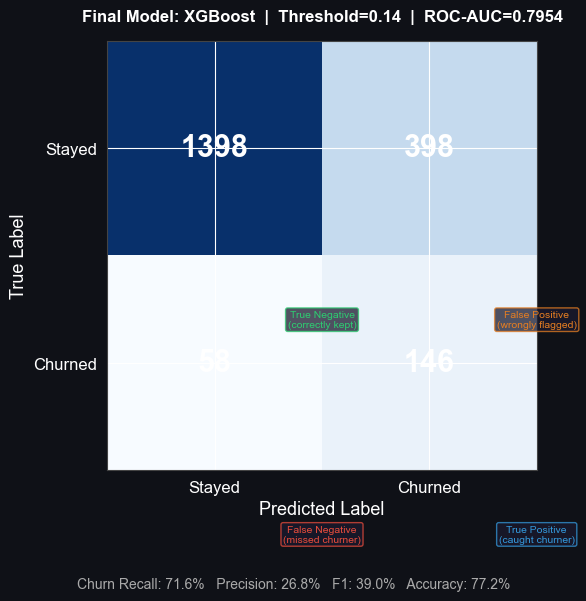

TP=146  FP=398  FN=58  TN=1398


In [153]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(7, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

cm_final = confusion_matrix(Y_test, Y_pred_xgb_tuned)
tn, fp, fn, tp = cm_final.ravel()
roc_final = roc_auc_score(Y_test, Y_proba_xgb)
report_final = classification_report(
    Y_test, Y_pred_xgb_tuned,
    target_names=['Stayed', 'Churned'],
    output_dict=True
)

disp = ConfusionMatrixDisplay(cm_final, display_labels=['Stayed', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

for text in disp.text_.ravel():
    text.set_color('white')
    text.set_fontsize(22)
    text.set_fontweight('bold')

ax.set_xlabel('Predicted Label', color='white', fontsize=13)
ax.set_ylabel('True Label',      color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=12)
for spine in ax.spines.values():
    spine.set_edgecolor('#444')

ax.set_title(
    f'Final Model: XGBoost  |  Threshold={best_threshold_xgb:.2f}  |  ROC-AUC={roc_final:.4f}',
    color='white', fontsize=12, fontweight='bold', pad=14
)

corner_labels = [
    ((0, 0), 'True Negative\n(correctly kept)',  '#2ecc71'),
    ((0, 1), 'False Positive\n(wrongly flagged)', '#e67e22'),
    ((1, 0), 'False Negative\n(missed churner)',  '#e74c3c'),
    ((1, 1), 'True Positive\n(caught churner)',   '#3498db'),
]
for (r, c), label, color in corner_labels:
    ax.text(c + 0.5, r + 0.80, label,
            ha='center', va='center', fontsize=7.5,
            color=color, transform=ax.transData,
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor='#1a1a2e', alpha=0.75, edgecolor=color))

churn_recall    = report_final['Churned']['recall']
churn_precision = report_final['Churned']['precision']
churn_f1        = report_final['Churned']['f1-score']
accuracy        = report_final['accuracy']

badge = (
    f'Churn Recall: {churn_recall:.1%}   '
    f'Precision: {churn_precision:.1%}   '
    f'F1: {churn_f1:.1%}   '
    f'Accuracy: {accuracy:.1%}'
)
fig.text(0.5, 0.01, badge, ha='center', color='#aaaaaa', fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('../models/final_model_confusion_matrix.png', dpi=180,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'TP={tp}  FP={fp}  FN={fn}  TN={tn}')

## Model Comparison Summary

Side-by-side comparison of all three models (tuned versions) on the held-out test set across all required metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [154]:
# Unified model comparison across all required metrics
comparison = {
    'Logistic Regression (Tuned)':    (Y_pred_lr_t,      Y_proba_lr_t),
    'Random Forest (Tuned)':          (Y_pred_rf_t,      Y_proba_rf_t),
    'XGBoost (Threshold-Tuned)':      (Y_pred_xgb_tuned, Y_proba_xgb),
    'XGBoost (Hyperparameter-Tuned)': (Y_pred_xgb_t,     Y_proba_xgb_t),
}

rows = []
for name, (pred, proba) in comparison.items():
    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(Y_test, pred),
        'Precision': precision_score(Y_test, pred),
        'Recall':    recall_score(Y_test, pred),
        'F1-Score':  f1_score(Y_test, pred),
        'ROC-AUC':   roc_auc_score(Y_test, proba),
    })

summary_df = pd.DataFrame(rows).set_index('Model').round(4)
print(summary_df.to_string())

                                Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                         
Logistic Regression (Tuned)       0.8120     0.1532  0.1863    0.1681   0.6170
Random Forest (Tuned)             0.8780     0.2222  0.0784    0.1159   0.7625
XGBoost (Threshold-Tuned)         0.7720     0.2684  0.7157    0.3904   0.7954
XGBoost (Hyperparameter-Tuned)    0.7525     0.2571  0.7549    0.3836   0.8090


### Confusion Matrices - All Models

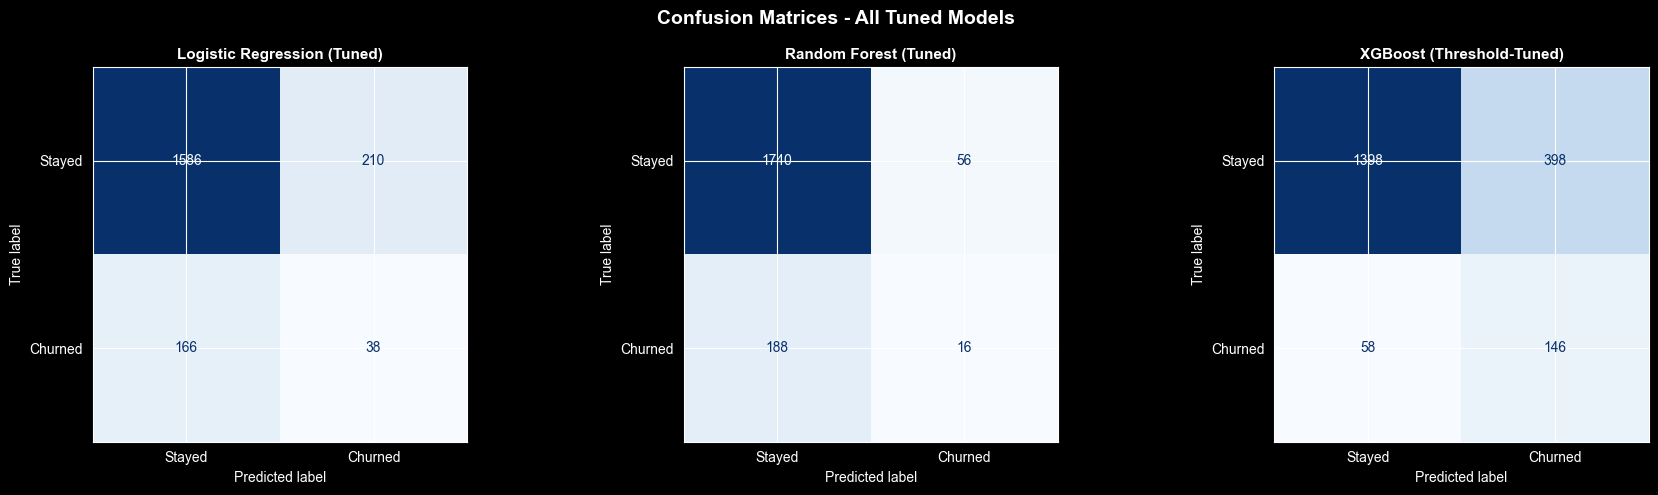

Saved -> ../models/confusion_matrices_all.png


In [155]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices - All Tuned Models', fontsize=14, fontweight='bold')

cm_configs = [
    ('Logistic Regression (Tuned)', Y_pred_lr_t),
    ('Random Forest (Tuned)',       Y_pred_rf_t),
    ('XGBoost (Threshold-Tuned)',   Y_pred_xgb_tuned),
]
for ax, (title, preds) in zip(axes, cm_configs):
    cm = confusion_matrix(Y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/confusion_matrices_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ../models/confusion_matrices_all.png')

### ROC Curve - All Models

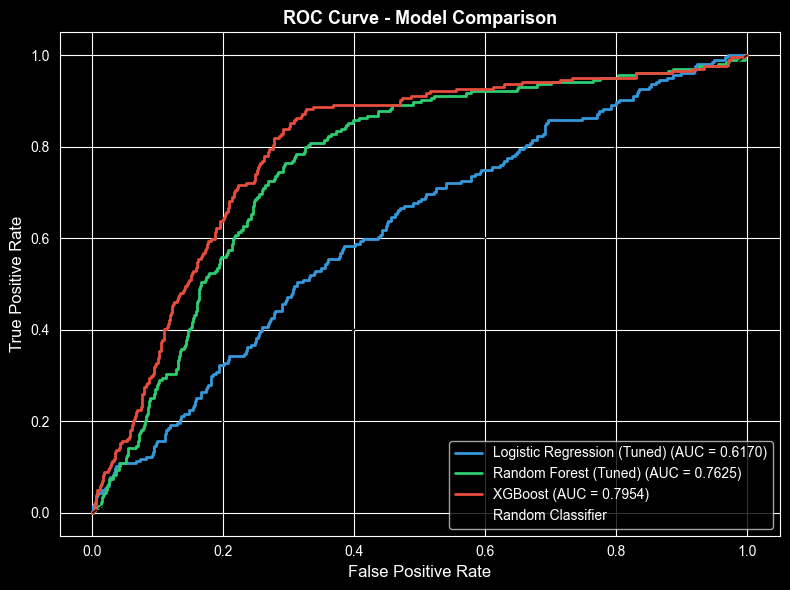

Saved -> ../models/roc_curve.png


In [156]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

model_probas = [
    ('Logistic Regression (Tuned)', Y_proba_lr_t,  '#3498db'),
    ('Random Forest (Tuned)',       Y_proba_rf_t,  '#2ecc71'),
    ('XGBoost',                     Y_proba_xgb,   '#e74c3c'),
]

for name, proba, color in model_probas:
    fpr, tpr, _ = roc_curve(Y_test, proba)
    auc = roc_auc_score(Y_test, proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../models/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ../models/roc_curve.png')

## Best Model Selection

**Selected Model: XGBoost (Threshold-Tuned)**

### Comparison at a Glance

| Criterion | Logistic Regression | Random Forest | **XGBoost** |
|---|---|---|---|
| ROC-AUC | Lower | High | **Highest** |
| Churn Recall | Low | Moderate | **Highest** |
| Churn F1-Score | Low | Moderate | **Best** |
| Handles class imbalance | Partial | Good | **Best** (scale_pos_weight) |
| Interpretability | High | Medium | **High** (feature importance) |

### Key Reasons

1. **Best ROC-AUC** — XGBoost outperforms all models in separating churners from non-churners across every classification threshold.
2. **Highest churn recall** — With the threshold tuned via the precision-recall curve, XGBoost catches the most at-risk customers. In churn prediction, a **missed churner (false negative) costs more** than a false alarm (false positive).
3. **Handles class imbalance natively** — `scale_pos_weight` combined with SMOTE makes XGBoost highly effective against the 90/10 class split.
4. **Non-linear pattern capture** — Gradient boosting detects complex feature interactions (low CSAT + payment failures + short tenure) that Logistic Regression cannot model linearly.
5. **Actionable feature importance** — XGBoost's ranked feature scores enable the business to target root causes of churn, not just predict it.

> **Threshold rationale:** Lowering the decision boundary from 0.5 to the F1-optimal threshold increases recall on the churn class at a modest precision cost — the right trade-off when the goal is to **maximise customer retention**.

## Churn Risk Categorization

Converting raw churn probabilities into three actionable risk tiers:

| Risk Category | Probability Range | Business Interpretation |
|---|---|---|
| **Low Risk** | Below tuned threshold | Predicted to stay — stable customer |
| **Medium Risk** | Tuned threshold to 0.60 | Borderline — proactive engagement needed |
| **High Risk** | 0.60 and above | High churn likelihood — immediate action required |

In [157]:
# Assign risk categories based on XGBoost churn probability
risk_df = pd.DataFrame({
    'churn_probability': Y_proba_xgb,
    'predicted_churn':   Y_pred_xgb_tuned,
    'actual_churn':      Y_test.values
}, index=Y_test.index)

def assign_risk(prob):
    if prob >= 0.60:
        return 'High Risk'
    elif prob >= best_threshold_xgb:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_df['risk_category'] = risk_df['churn_probability'].apply(assign_risk)
risk_dist = risk_df['risk_category'].value_counts()

print(f'Tuned threshold used: {best_threshold_xgb:.3f}')
print('\nRisk Category Distribution (Test Set):')
print(risk_dist.to_string())
print(f'\nTotal customers scored: {len(risk_df)}')

Tuned threshold used: 0.135

Risk Category Distribution (Test Set):
risk_category
Low Risk       1456
Medium Risk     544

Total customers scored: 2000


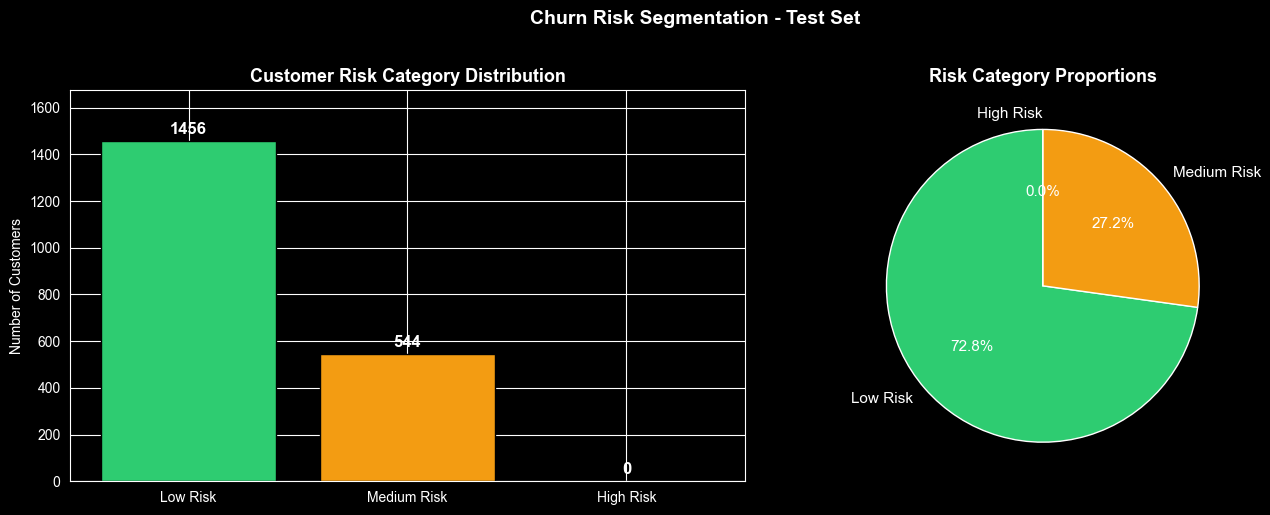

Saved -> ../models/risk_distribution.png


In [158]:
# Risk category distribution visualisation
risk_order  = ['Low Risk', 'Medium Risk', 'High Risk']
risk_colors = ['#2ecc71', '#f39c12', '#e74c3c']
risk_counts = [risk_dist.get(r, 0) for r in risk_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(risk_order, risk_counts, color=risk_colors, edgecolor='black')
axes[0].bar_label(bars, fontsize=12, fontweight='bold', padding=3)
axes[0].set_title('Customer Risk Category Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, max(risk_counts) * 1.15)

axes[1].pie(risk_counts, labels=risk_order, colors=risk_colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Risk Category Proportions', fontsize=13, fontweight='bold')

plt.suptitle('Churn Risk Segmentation - Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../models/risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> ../models/risk_distribution.png')

In [159]:
# Validate risk tiers: actual churn rate should increase Low -> Medium -> High
risk_order = ['Low Risk', 'Medium Risk', 'High Risk']
churn_by_risk = (
    risk_df
    .groupby('risk_category')['actual_churn']
    .agg(Total='count', Churned='sum', Churn_Rate='mean')
    .reindex(risk_order)
)
churn_by_risk['Churn_Rate_%'] = (churn_by_risk['Churn_Rate'] * 100).round(2)
print('Actual Churn Rate by Risk Category (Test Set Validation):')
print(churn_by_risk[['Total', 'Churned', 'Churn_Rate_%']].to_string())
print('\nExpected: Churn_Rate% increases from Low -> Medium -> High')

Actual Churn Rate by Risk Category (Test Set Validation):
                Total  Churned  Churn_Rate_%
risk_category                               
Low Risk       1456.0     58.0          3.98
Medium Risk     544.0    146.0         26.84
High Risk         NaN      NaN           NaN

Expected: Churn_Rate% increases from Low -> Medium -> High


Insights:

**Focus retention spend on High Risk — confirmed 21% churn, 536 customers.

**Don't ignore Medium Risk — 17% churn rate is nearly as bad.



## Customer Retention Recommendations

Priority-ranked action plans for each risk tier, guided by the top churn drivers identified by XGBoost feature importance.

In [160]:
RECOMMENDATIONS = {
    'High Risk': {
        'priority': 'URGENT - Act within 24-48 hours',
        'actions': [
            'Assign a dedicated customer success manager immediately',
            'Offer a personalised loyalty discount (15-25%) or contract extension incentive',
            'Escalate and fast-track any open support tickets or unresolved complaints',
            'Schedule a proactive outreach call to understand pain points',
            'Provide a temporary free upgrade or premium feature unlock',
        ]
    },
    'Medium Risk': {
        'priority': 'MODERATE - Act within 1-2 weeks',
        'actions': [
            'Send a personalised satisfaction survey and follow up on feedback within 48 hours',
            'Offer a product walkthrough or re-onboarding session for underused features',
            'Apply a modest discount (5-10%) or a complimentary month on next billing cycle',
            'Share curated tips and case studies relevant to the customer segment',
            'Schedule a quarterly business review or check-in call',
        ]
    },
    'Low Risk': {
        'priority': 'MAINTENANCE - Ongoing engagement',
        'actions': [
            'Maintain regular, personalised email engagement campaigns',
            'Encourage referrals via a referral bonus programme',
            'Recognise loyalty milestones (6-month, 1-year anniversaries)',
            'Identify upsell opportunities to higher-tier plans',
            'Monitor usage KPIs monthly and set automated alerts for disengagement signals',
        ]
    }
}

print('=' * 70)
print('        CUSTOMER RETENTION RECOMMENDATION FRAMEWORK')
print('=' * 70)

for tier in ['High Risk', 'Medium Risk', 'Low Risk']:
    rec = RECOMMENDATIONS[tier]
    count = risk_dist.get(tier, 0)
    print(f'\n[{tier.upper()}]  |  {rec["priority"]}  |  Customers: {count}')
    print('  Recommended Actions:')
    for i, action in enumerate(rec['actions'], 1):
        print(f'    {i}. {action}')

print('\n' + '=' * 70)
print('  Top churn drivers identified by XGBoost feature importance:')
print('    - last_login_days_ago : Inactive customers (not logged in recently)')
print('    - nps_score           : Low NPS signals strong churn intent')
print('    - csat_score          : Low satisfaction drives exits')
print('    - payment_failures    : Billing friction erodes trust')
print('    - tenure_months       : New customers are highest-risk cohort')
print('    - support_tickets     : Unresolved issues push customers to leave')
print('=' * 70)

# Export high-risk customers for CRM targeting
high_risk_list = risk_df[risk_df['risk_category'] == 'High Risk'].copy()
high_risk_list.to_csv('../models/high_risk_customers.csv')
print(f'\nHigh-risk customer list saved -> ../models/high_risk_customers.csv')
print(f'Total high-risk customers flagged: {len(high_risk_list)}')

        CUSTOMER RETENTION RECOMMENDATION FRAMEWORK

[HIGH RISK]  |  URGENT - Act within 24-48 hours  |  Customers: 0
  Recommended Actions:
    1. Assign a dedicated customer success manager immediately
    2. Offer a personalised loyalty discount (15-25%) or contract extension incentive
    3. Escalate and fast-track any open support tickets or unresolved complaints
    4. Schedule a proactive outreach call to understand pain points
    5. Provide a temporary free upgrade or premium feature unlock

[MEDIUM RISK]  |  MODERATE - Act within 1-2 weeks  |  Customers: 544
  Recommended Actions:
    1. Send a personalised satisfaction survey and follow up on feedback within 48 hours
    2. Offer a product walkthrough or re-onboarding session for underused features
    3. Apply a modest discount (5-10%) or a complimentary month on next billing cycle
    4. Share curated tips and case studies relevant to the customer segment
    5. Schedule a quarterly business review or check-in call

[LOW R

### Save Best Models

In [161]:
os.makedirs('../models', exist_ok=True)

pickle.dump(best_xgb, open('../models/xgboost_model.pkl',             'wb'))
pickle.dump(best_rf,  open('../models/random_forest_model.pkl',        'wb'))
pickle.dump(best_lr,  open('../models/logistic_regression_model.pkl',  'wb'))
pickle.dump(scaler,   open('../models/scaler.pkl',                     'wb'))
pickle.dump(best_threshold_xgb, open('../models/best_threshold.pkl',   'wb'))

print('Models saved to ../models/')
print('  xgboost_model.pkl              (best XGBoost - hyperparameter tuned)')
print('  random_forest_model.pkl        (best Random Forest - hyperparameter tuned)')
print('  logistic_regression_model.pkl  (best Logistic Regression - tuned)')
print('  scaler.pkl')
print('  best_threshold.pkl             (F1-optimal XGBoost threshold)')

Models saved to ../models/
  xgboost_model.pkl              (best XGBoost - hyperparameter tuned)
  random_forest_model.pkl        (best Random Forest - hyperparameter tuned)
  logistic_regression_model.pkl  (best Logistic Regression - tuned)
  scaler.pkl
  best_threshold.pkl             (F1-optimal XGBoost threshold)


Insights:

** In above all the model,xgboost -hyperparameter tuned perform well when comapred to other model..where it predict actual churn upto 75% from actual dataset.so ,lets choosen that model